<a href="https://colab.research.google.com/github/HarnilModi22/Unveiling-the-Android-App-Market-Analyzing-Google-Play-Store-Data/blob/main/Analyzing_Google_Play_Store_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unveiling the Android App Market: Analyzing Google Play Store Data

# Introduction

The project “Unveiling the Android App Market: Analyzing Google Play Store Data” focuses on analyzing Google Play Store datasets to understand app market trends, user behavior, and app performance. Using Python libraries such as Pandas, NumPy, Matplotlib, Seaborn, Plotly, and TextBlob, the project performs data cleaning, exploratory data analysis, visualization, and sentiment analysis on app ratings, installs, reviews, pricing, and categories. The main objective is to gain meaningful insights into the Android app ecosystem through interactive visualizations and user review analysis while improving practical skills in data analytics and visualization.

# Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud
from textblob import TextBlob

import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10,6)

# Load Dataset

In [ ]:
apps_df = pd.read_csv('/content/apps (1).csv')
reviews_df = pd.read_csv('/content/user_reviews (1).csv')

# Display first rows
print("Apps Dataset")
apps_df.head()

Apps Dataset


,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [ ]:
print("Reviews Dataset")
reviews_df.head()

Reviews Dataset


,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


# Dataset Information

In [ ]:
print("Apps Dataset Shape:", apps_df.shape)
print("Reviews Dataset Shape:", reviews_df.shape)

Apps Dataset Shape: (9659, 14)
Reviews Dataset Shape: (64295, 5)


In [ ]:
apps_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9659 entries, 0 to 9658
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      9659 non-null   int64  
 1   App             9659 non-null   object 
 2   Category        9659 non-null   object 
 3   Rating          8196 non-null   float64
 4   Reviews         9659 non-null   int64  
 5   Size            8432 non-null   float64
 6   Installs        9659 non-null   object 
 7   Type            9659 non-null   object 
 8   Price           9659 non-null   object 
 9   Content Rating  9659 non-null   object 
 10  Genres          9659 non-null   object 
 11  Last Updated    9659 non-null   object 
 12  Current Ver     9651 non-null   object 
 13  Android Ver     9657 non-null   object 
dtypes: float64(2), int64(2), object(10)
memory usage: 1.0+ MB


In [ ]:
reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  object 
 1   Translated_Review       37427 non-null  object 
 2   Sentiment               37432 non-null  object 
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), object(3)
memory usage: 2.5+ MB


In [ ]:
apps_df.isnull().sum()

,0
Unnamed: 0,0
App,0
Category,0
Rating,1463
Reviews,0
Size,1227
Installs,0
Type,0
Price,0
Content Rating,0


In [ ]:
reviews_df.isnull().sum()

,0
App,0
Translated_Review,26868
Sentiment,26863
Sentiment_Polarity,26863
Sentiment_Subjectivity,26863


# Data Cleaning

In [ ]:
apps_df.drop_duplicates(inplace=True)

# Remove rows where Android Ver is missing
apps_df = apps_df[apps_df['Android Ver'].notna()]

# Remove rows where Rating is missing
apps_df = apps_df[apps_df['Rating'].notna()]

# Clean Installs Column

In [ ]:
apps_df['Installs'] = apps_df['Installs'].str.replace(',', '')
apps_df['Installs'] = apps_df['Installs'].str.replace('+', '')

apps_df['Installs'] = apps_df['Installs'].astype(int)

apps_df[['App', 'Installs']].head()

,App,Installs
0,Photo Editor & Candy Camera & Grid & ScrapBook,10000
1,Coloring book moana,500000
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",5000000
3,Sketch - Draw & Paint,50000000
4,Pixel Draw - Number Art Coloring Book,100000


# Clean Price Column

In [ ]:
apps_df['Price'] = apps_df['Price'].str.replace('$', '')
apps_df['Price'] = apps_df['Price'].astype(float)

apps_df[['App', 'Price']].head()

,App,Price
0,Photo Editor & Candy Camera & Grid & ScrapBook,0.0
1,Coloring book moana,0.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",0.0
3,Sketch - Draw & Paint,0.0
4,Pixel Draw - Number Art Coloring Book,0.0


# Clean Size Column

In [ ]:
apps_df['Size'] = apps_df['Size'].astype(str)

# Function to convert size
def convert_size(size):

    if pd.isnull(size):
        return np.nan

    # Convert to string
    size = str(size)

    if 'M' in size:
        return float(size.replace('M', ''))

    elif 'k' in size:
        return float(size.replace('k', '')) / 1024

    else:
        return np.nan

# Apply function
apps_df['Size'] = apps_df['Size'].apply(convert_size)

# Category Exploration

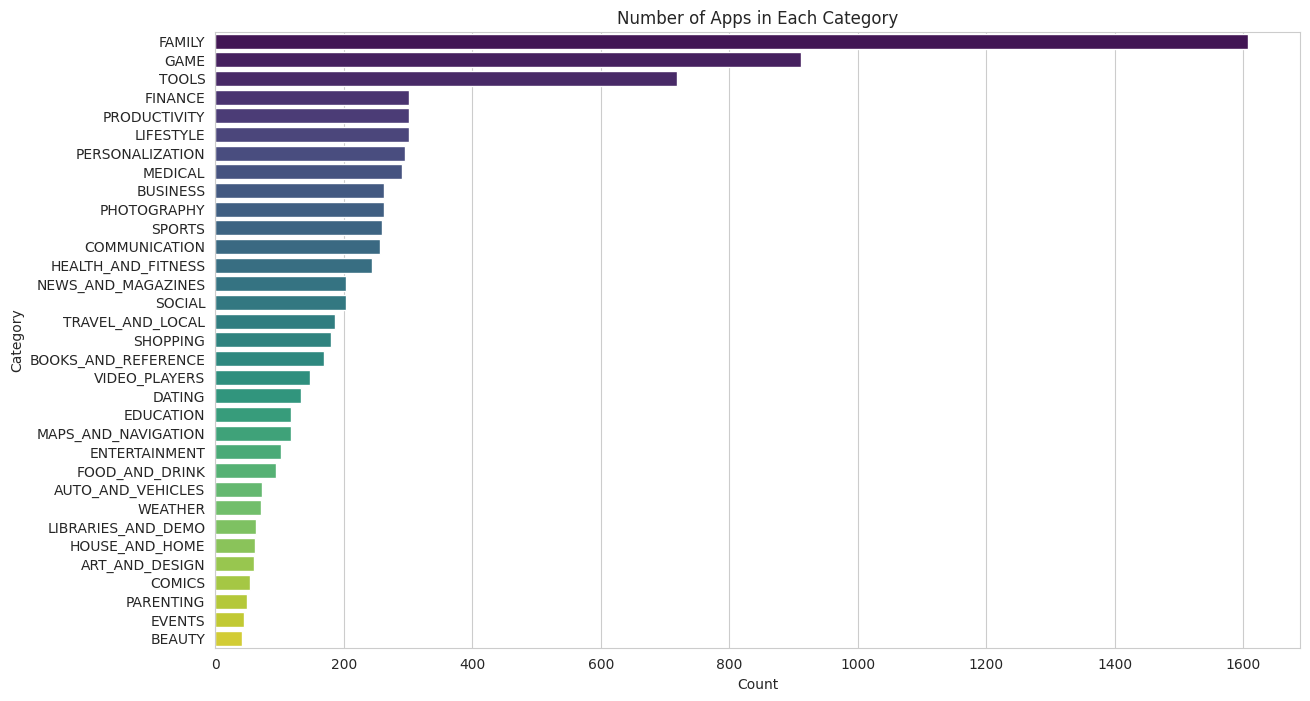

In [ ]:
category_counts = apps_df['Category'].value_counts()

plt.figure(figsize=(14,8))
sns.barplot(x=category_counts.values,
            y=category_counts.index,
            palette='viridis')

plt.title('Number of Apps in Each Category')
plt.xlabel('Count')
plt.ylabel('Category')
plt.show()

# App Ratings Distribution

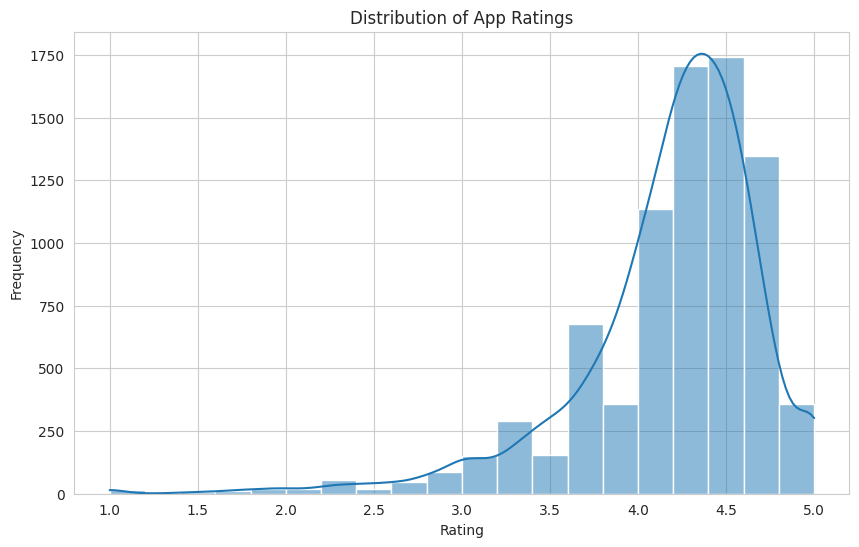

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(apps_df['Rating'], bins=20, kde=True)

plt.title('Distribution of App Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

# Top 10 Categories by Average Rating

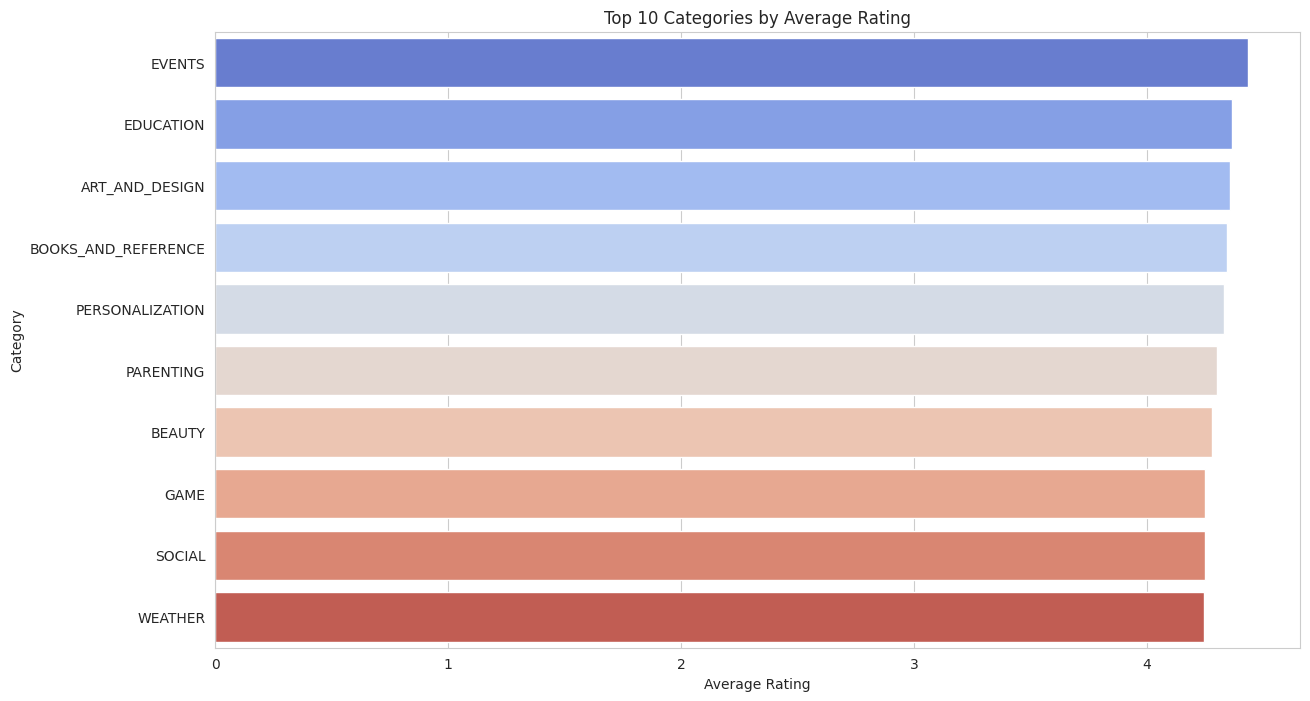

In [ ]:
avg_rating = apps_df.groupby('Category')['Rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(14,8))

sns.barplot(x=avg_rating.values[:10],
            y=avg_rating.index[:10],
            palette='coolwarm')

plt.title('Top 10 Categories by Average Rating')
plt.xlabel('Average Rating')
plt.ylabel('Category')
plt.show()

# Free vs Paid Apps

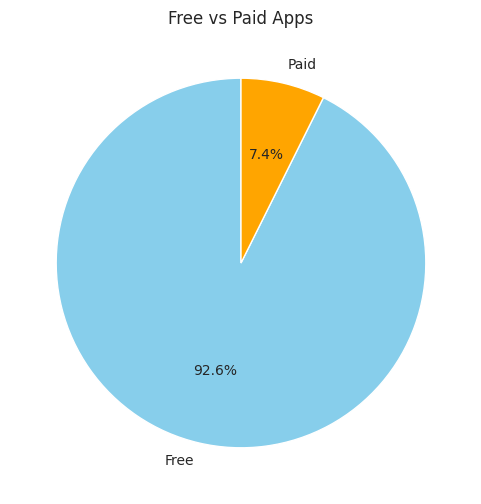

In [ ]:
type_counts = apps_df['Type'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(type_counts,
        labels=type_counts.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=['skyblue', 'orange'])

plt.title('Free vs Paid Apps')
plt.show()

# Top 10 Most Installed Apps

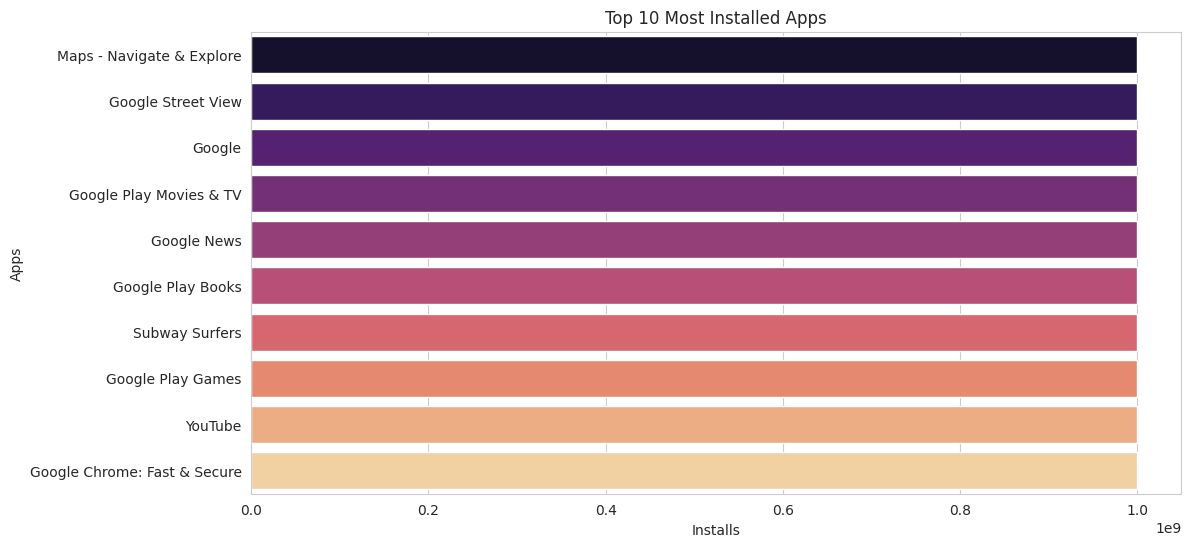

In [ ]:
most_installed = apps_df[['App', 'Installs']].sort_values(by='Installs', ascending=False).head(10)

plt.figure(figsize=(12,6))

sns.barplot(x='Installs', y='App', data=most_installed, palette='magma')

plt.title('Top 10 Most Installed Apps')
plt.xlabel('Installs')
plt.ylabel('Apps')
plt.show()

# Correlation Heatmap

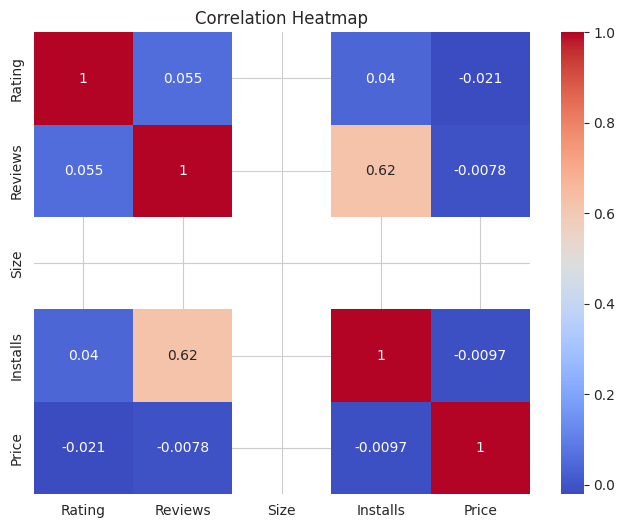

In [ ]:
numeric_df = apps_df[['Rating', 'Reviews', 'Size', 'Installs', 'Price']]

# Convert Reviews to numeric
numeric_df['Reviews'] = pd.to_numeric(numeric_df['Reviews'])

plt.figure(figsize=(8,6))

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

# Sentiment Analysis

In [ ]:
reviews_df.dropna(inplace=True)

# Function to get sentiment polarity

def get_sentiment(text):
    return TextBlob(str(text)).sentiment.polarity

reviews_df['Sentiment_Polarity'] = reviews_df['Translated_Review'].apply(get_sentiment)

reviews_df[['Translated_Review', 'Sentiment_Polarity']].head()

,Translated_Review,Sentiment_Polarity
0,I like eat delicious food. That's I'm cooking ...,1.00
1,This help eating healthy exercise regular basis,0.25
3,Works great especially going grocery store,0.40
4,Best idea us,1.00
5,Best way,1.00


# Sentiment Distribution

<function matplotlib.pyplot.show(close=None, block=None)>

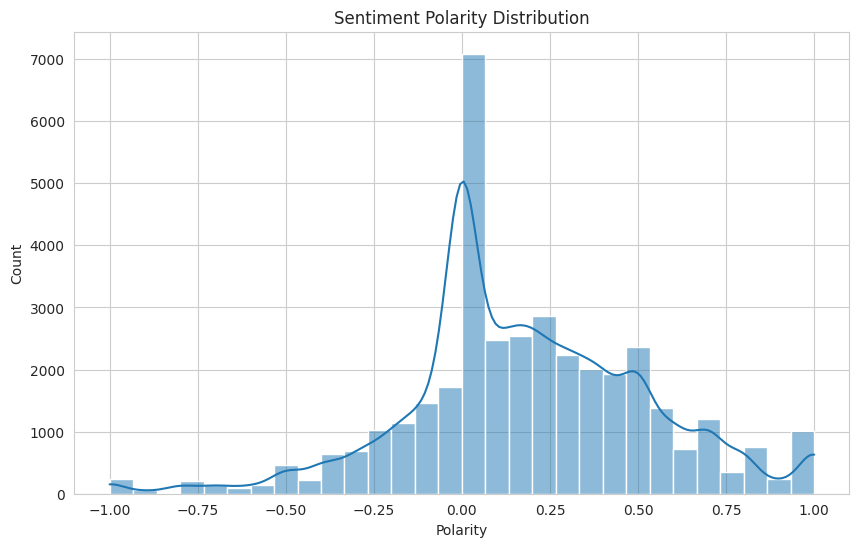

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(reviews_df['Sentiment_Polarity'], bins=30, kde=True)

plt.title('Sentiment Polarity Distribution')
plt.xlabel('Polarity')
plt.ylabel('Count')
plt.show

# Sentiment Count Plot

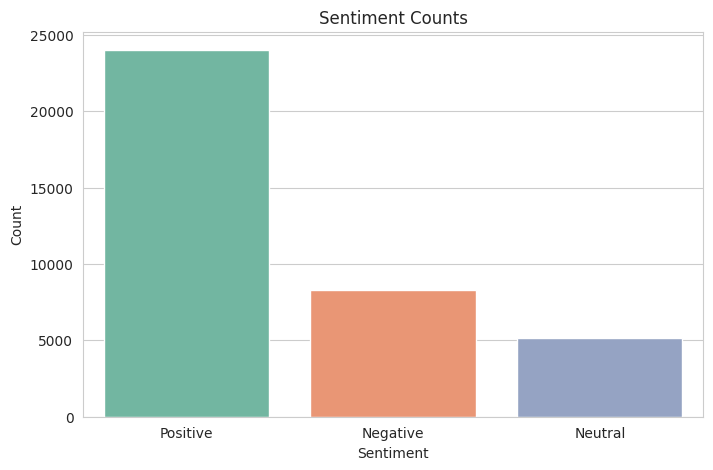

In [ ]:
sentiment_counts = reviews_df['Sentiment'].value_counts()

plt.figure(figsize=(8,5))

sns.barplot(x=sentiment_counts.index,
            y=sentiment_counts.values,
            palette='Set2')

plt.title('Sentiment Counts')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

# Word Cloud

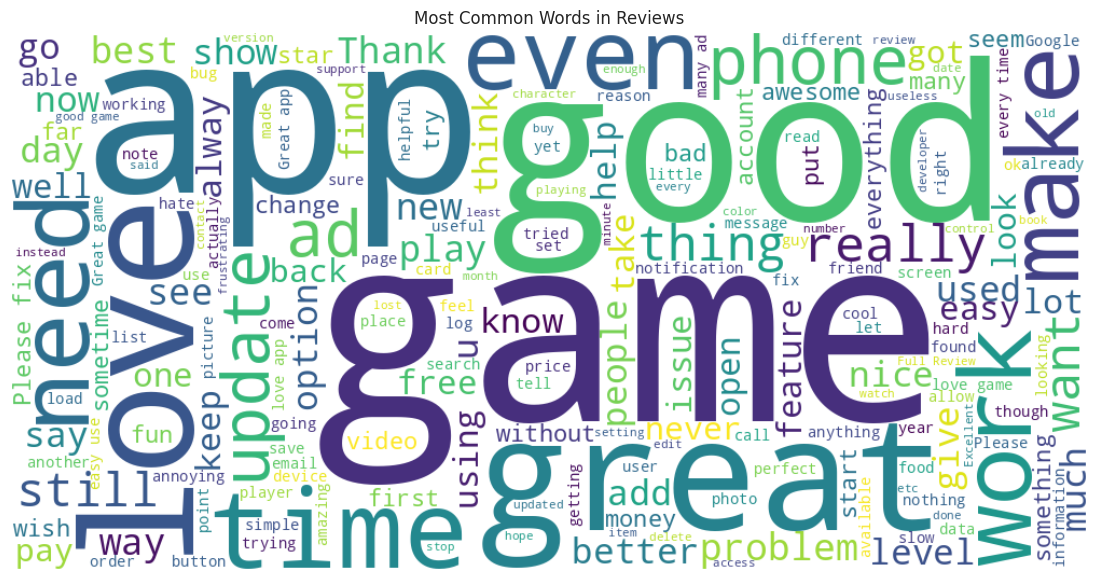

In [ ]:
text = ' '.join(reviews_df['Translated_Review'].astype(str))

wordcloud = WordCloud(width=1000,
                      height=500,
                      background_color='white').generate(text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Reviews')
plt.show()

Interactive Visualization using Plotly

In [ ]:
import plotly.express as px

category_install = apps_df.groupby('Category')['Installs'].sum().reset_index()

fig = px.bar(category_install,
             x='Category',
             y='Installs',
             color='Installs',
             title='Total Installs by Category')

fig.show()

# Top Rated Apps

In [ ]:
top_rated = apps_df[['App', 'Category', 'Rating']].sort_values(by='Rating', ascending=False).head(20)

print(top_rated)

                                                    App      Category  Rating
9594                                   Monster Ride Pro          GAME     5.0
9638                                    Fr. Daoud Lamei        FAMILY     5.0
9655                   Fr. Mike Schmitz Audio Teachings        FAMILY     5.0
6483                                           Color CL     LIFESTYLE     5.0
6467                                        CL Notifier         TOOLS     5.0
6464            CL Keyboard - Myanmar Keyboard (No Ads)         TOOLS     5.0
6456                                            CL REPL         TOOLS     5.0
6433                                         Tic Tac CK        FAMILY     5.0
6429                                 CK Employee Portal      BUSINESS     5.0
6428                         USMLE Step 2 CK Flashcards        FAMILY     5.0
6417                                             211:CK          GAME     5.0
6783                        CS & IT Interview Questions        F

# Install Required Libraries

In [ ]:
!pip install textblob
!pip install wordcloud
!pip install plotly

# Final Insights

In [ ]:
print('Total Apps:', apps_df.shape[0])
print('Total Categories:', apps_df['Category'].nunique())
print('Highest Rated App:', apps_df.loc[apps_df['Rating'].idxmax(), 'App'])
print('Most Installed App:', apps_df.loc[apps_df['Installs'].idxmax(), 'App'])

Total Apps: 8194
Total Categories: 33
Highest Rated App: Hojiboy Tojiboyev Life Hacks
Most Installed App: Google Play Books


# Result

The analysis of the Google Play Store dataset successfully provided insights into Android app market trends, user preferences, and app performance. The project identified the most popular app categories, highly rated applications, install trends, and the difference between free and paid apps. Sentiment analysis of user reviews revealed overall positive, negative, and neutral user opinions about applications. Various visualizations and interactive charts helped in understanding relationships between app ratings, reviews, installs, size, and pricing. Overall, the project demonstrated the effectiveness of data analytics and visualization techniques in extracting meaningful information from large-scale app market data.
